# Terzan 5 Globular Cluster

This work has made use of data from the European Space Agency (ESA) mission Gaia (https://www.cosmos.esa.int/gaia), processed by the Gaia Data Processing and Analysis Consortium (DPAC, https://www.cosmos.esa.int/web/gaia/dpac/consortium). Funding for the DPAC has been provided by national institutions, in particular the institutions participating in the Gaia Multilateral Agreement.



In [78]:
import numpy as np
import math
import matplotlib.pyplot as plt
cluster_data=np.loadtxt('full_data.csv',delimiter=',') #Loading the Data


In [79]:
length,b=np.shape(cluster_data) #Finding the no. of entries in the dataset

In [80]:
length #Checking the no. of elements in the dataset

7526

In [81]:
cluster_data[1][1]  #Checking the element 
#cluster_data[1][1] gives the Ra, 

266.97981874519013

In [82]:
#Converting the ra,dec into radians
for i in range(length):
    cluster_data[i][1]=cluster_data[i][1]*np.pi/180
    cluster_data[i][2]=cluster_data[i][2]*np.pi/180

In [83]:
cluster_data[1][1] #Checking whether the value was converted to radian or not

4.659676873481244

In [84]:
#Now we are taking the values of the center of the cluster in radians 
ra1= 267.02083333*np.pi/180
dec1= -24.78*np.pi/180

In [85]:
ra1,dec1 #Ra and Dec of the Center of the Cluster in  Radians

(4.660392713027515, -0.4324925886441948)

The angular difference between two points given their Ra and Dec is given by $$cos(\theta)=sin(\delta_1)sin(\delta_2)+cos(\delta_1)cos(\delta_2)cos(\alpha_1-\alpha_2)$$
Where $\delta_1$ and $\delta_2$ denotes the declination of the two objects respectively, $\alpha_1$ and $\alpha_2$ denotes the right ascension of the two objects respectively, and $\theta$ denotes the angular separation between them.Where $\delta_1$ and $\delta_2$ denotes the declination of the two objects respectively, $\alpha_1$ and $\alpha_2$ denotes the right ascension of the two objects respectively, and $\theta$ denotes the angular separation between them.

In [86]:
#Find the anglular differece btw each point and the center
sep_list=[]
#Iterating over the whole dataset
for i in range(length):
    ra=cluster_data[i][1]
    dec=cluster_data[i][2]
    #We find the cosine of the angle of seperation
    cosine_value=np.sin(dec1)*np.sin(dec)+np.cos(dec1)*np.cos(dec)*np.cos(ra1-ra)
    seperation=math.acos(cosine_value)*(180/(np.pi)) #Taking Cosine Inverse and Converting back into degrees
    sep_list.append(seperation) #Appending the distance from center into a list          

In [87]:
sep_list=np.array(sep_list) #List containing distances of each star from the center of the cluster

In [88]:
len(sep_list)

7526

In [89]:
max(sep_list)*60
#The maximim distance from the center of a point ( in arc minutes) 

4.000150989865669

We now take 27 eqally spaced elements in a numpy array from 0 to the maximum radius in our dataset.
You can change the number 27 to `n`to create a numpy array with `n` elements which are equally spaced 

In [90]:
x=np.linspace(0,max(sep_list),25)
#Now converting values in x from degrees to arcminutes
z=x*60
##Now z is in arc minutes

In [91]:
len(z) #Checking the length of the numpy array

25

We now find the number of stars within circles of increasing radius `r` where `r` values are equally spaced and range of r is   0 to ~8 arcmin from the center of the cluster

In [92]:
#Emplty list
number=[]
for i in range(len(x)):
    count=0
    for j in range(len(sep_list)):
        if sep_list[j]<x[i]:
            count+=1
    number.append(count) #We add the number of elements within a radius of elements in  
    

In [93]:
len(number)

25

In [94]:
for i in range(len(number)-1):
    number[i]=number[i+1]-number[i]
    #Finding the no. of stars in different sectors

In [95]:
number.remove(7525)  #Removing the last element

In [96]:
len(number)

24

We divide the entire area into 27 sectors and find the number of stars per square min
$$density= \frac{no. of elements}{\pi R^2-\pi r^2}$$

In [97]:
#Here we find density per sq minutenow
density_per_sq_min=[]
for i in range(len(number)):
    y=number[i]/(np.pi*(z[i+1]**2)-np.pi*(z[i]**2))
    density_per_sq_min.append(y)    

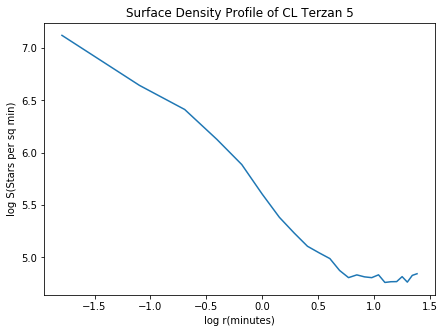

In [98]:
#Now we plot logarithm of density per arc min vs logrithm of radius
plt.figure(figsize=(7,5))
a=np.delete(z,0) #We remove zero since log 0 is not defined
plt.ylabel('log S(Stars per sq min)')
plt.xlabel('log r(minutes)')
plt.title('Surface Density Profile of CL Terzan 5')
plt.plot(np.log(a),np.log(density_per_sq_min))
plt.show()

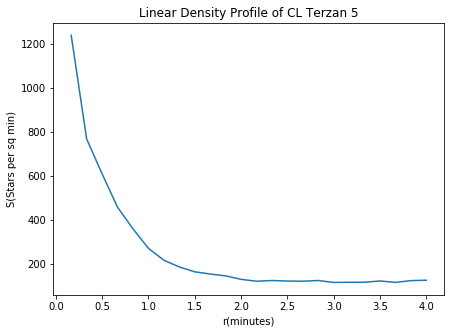

In [102]:
#Plotting the same graph on a linear scale
plt.figure(figsize=(7,5))
a=np.delete(z,0) #We remove zero since log 0 is not defined
plt.ylabel('S(Stars per sq min)')
plt.xlabel('r(minutes)')
plt.title('Linear Density Profile of CL Terzan 5')
plt.plot(a,density_per_sq_min)
plt.show()